## The Z-Score

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
from IPython.display import display

customers = pd.read_csv('Wholesale_customers_data.csv')
customers.Region = customers.Region.astype('category')
customers.Channel = customers.Channel.astype('category')

In [2]:
customers.shape

(440, 8)

In [3]:
customers.select_dtypes(include=['int64']).shape

(440, 6)

In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Channel           440 non-null    category
 1   Region            440 non-null    category
 2   Fresh             440 non-null    int64   
 3   Milk              440 non-null    int64   
 4   Grocery           440 non-null    int64   
 5   Frozen            440 non-null    int64   
 6   Detergents_Paper  440 non-null    int64   
 7   Delicatessen      440 non-null    int64   
dtypes: category(2), int64(6)
memory usage: 21.9 KB


In [5]:
pd.__version__

'2.2.3'

In [6]:
customer_features = customers.select_dtypes(exclude = ['category'])

display(customers.info())
display(customers.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Channel           440 non-null    category
 1   Region            440 non-null    category
 2   Fresh             440 non-null    int64   
 3   Milk              440 non-null    int64   
 4   Grocery           440 non-null    int64   
 5   Frozen            440 non-null    int64   
 6   Detergents_Paper  440 non-null    int64   
 7   Delicatessen      440 non-null    int64   
dtypes: category(2), int64(6)
memory usage: 21.9 KB


None

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [7]:
customer_features.dtypes

Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicatessen        int64
dtype: object

<a id='review-statistics-parameters'></a>

#### Review: Sample Statistics and Parameters

---

Recall that we use sample statistics to estimate population parameters. Our goal is to calculate sample statistics and then rely on properties of a random sample (and perhaps additional assumptions) to make inferences that we can generalize to the larger population of interest.

Below is a table comparing some example sample statistics and population parameters:

Metric  | Statistic  | Parameter 
-------- | ---------- | -------- 
mean   | $$\bar{x} = \frac{\sum x}{n}$$ | $$ \mu = \frac{\sum x}{N} $$      
standard deviation   | $$ s = \sqrt{\frac{\sum_i (x_i - \bar{x})^2}{n-1}} $$ | $$ \sigma = \sqrt{\frac{\sum_i (x_i - \mu)^2}{N} } $$
correlation   | $$ r = \frac{\hat{Cov}(X, Y)}{s_X s_Y} $$ | $$ \rho = \frac{Cov(X, Y)}{\sigma_X \sigma_Y} $$

### The Normal Distribution

---

The normal distribution is arguably the most commonly used distribution in all of statistics. **Normality** is an assumption that underlies many statistical tests and serves as a convenient model for the distribution of many (but not all!) variables.

The normal distribution relies on two parameters: 
- The population mean
- The population standard deviation 

If a variable follows a Normal distribution exactly, its mean, median, and mode will all be equal.

In [11]:
list(range(5))

[0, 1, 2, 3, 4]

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/3001775546.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(yy)
/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/3001775546.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(yy)
/var/folders/4_/5nh7mgns3q97l87b

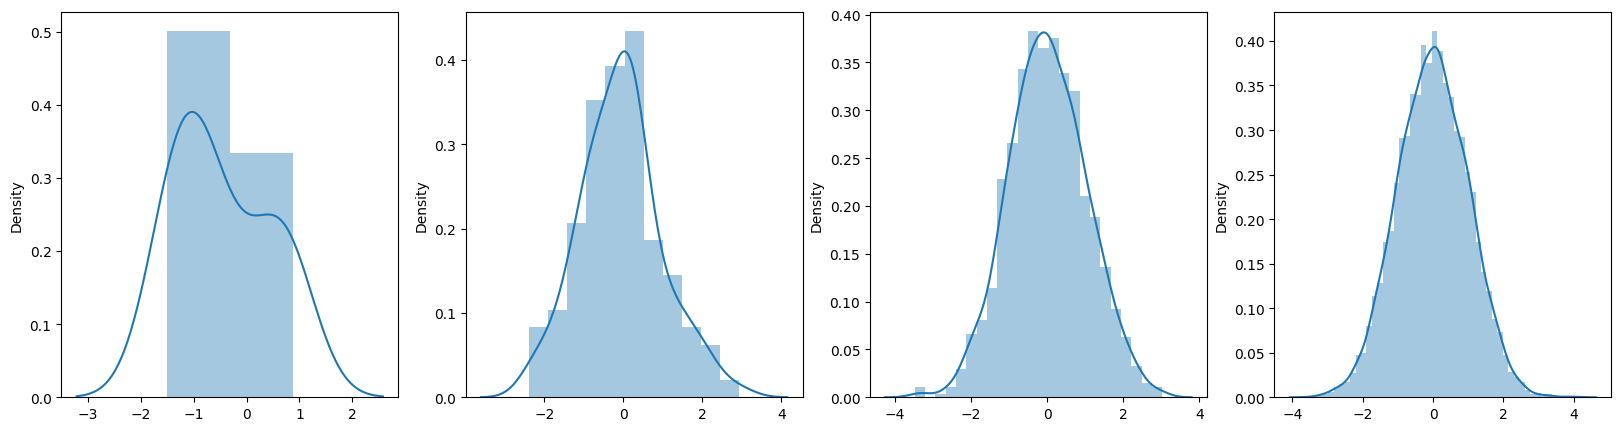

In [10]:
fig = plt.figure(figsize=(20,5))

for i in range(1,5):
    yy = np.random.normal(size=10**i)
    fig.add_subplot(1,4,i)
    sns.distplot(yy)

In [18]:
import scipy
import sklearn
import pandas

np, np.linalg, scipy.stats, sklearn, pandas

(<module 'numpy' from '/opt/miniconda3/envs/la-goose/lib/python3.12/site-packages/numpy/__init__.py'>,
 <module 'numpy.linalg' from '/opt/miniconda3/envs/la-goose/lib/python3.12/site-packages/numpy/linalg/__init__.py'>,
 <module 'scipy.stats' from '/opt/miniconda3/envs/la-goose/lib/python3.12/site-packages/scipy/stats/__init__.py'>,
 <module 'sklearn' from '/opt/miniconda3/envs/la-goose/lib/python3.12/site-packages/sklearn/__init__.py'>,
 <module 'pandas' from '/opt/miniconda3/envs/la-goose/lib/python3.12/site-packages/pandas/__init__.py'>)

<a id='zdist-rule'></a>

#### The 68-95-99.7 Rule

---

It is often beneficial to identify how extreme (or far away from the expected value) a particular observation is within the context of a distribution. 

It is possible to show that, for a Normal distribution:
- 68% of observations from a population will fall within $\pm 1$ standard deviation of the population mean.
- 95% of observations from a population will fall within $\pm 2$ standard deviations of the population mean.
- 99.7% of observations from a population will fall within $\pm 3$ standard deviations of the population mean.

**Below is a visual representation of the 68-95-99.7 rule on the Delicatessen distribution:**

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/2379676126.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customers.Delicatessen)


(-5000.0, 20000.0)

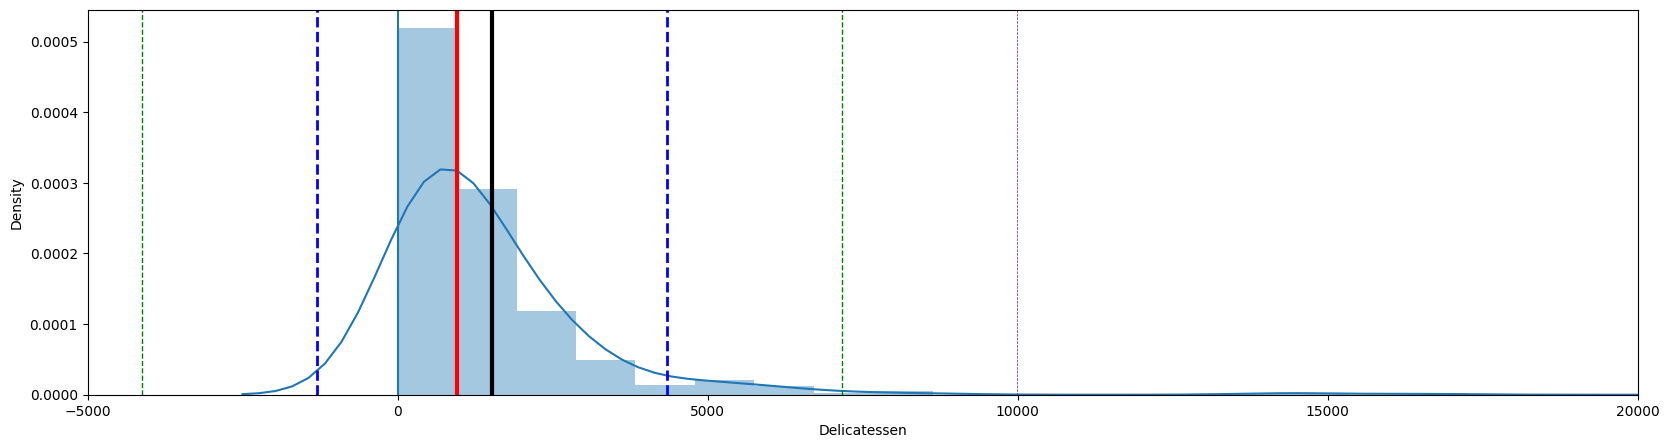

In [24]:
plt.figure(figsize=(20,5))

sns.distplot(customers.Delicatessen)

plt.axvline(customers.Delicatessen.mean(), color='black', lw=3)
plt.axvline(customers.Delicatessen.median(), color='red', lw=3)
plt.axvline((customers.Delicatessen.mean() - customers.Delicatessen.std()),
            color='blue', lw=2, ls="dashed")
plt.axvline((customers.Delicatessen.mean() + customers.Delicatessen.std()),
            color='blue', lw=2, ls="dashed")
plt.axvline((customers.Delicatessen.mean() + 2*customers.Delicatessen.std()),
            color='green', lw=1, ls="dashed")
plt.axvline((customers.Delicatessen.mean() - 2*customers.Delicatessen.std()),
            color='green', lw=1, ls="dashed")
plt.axvline((customers.Delicatessen.mean() + 3*customers.Delicatessen.std()),
            color='purple', lw=.5, ls="dashed")
plt.axvline((customers.Delicatessen.mean() - 3*customers.Delicatessen.std()),
            color='purple', lw=.5, ls="dashed")
plt.axvline(0)
plt.xlim(-5000,20000)

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/3730316992.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(log_deli)


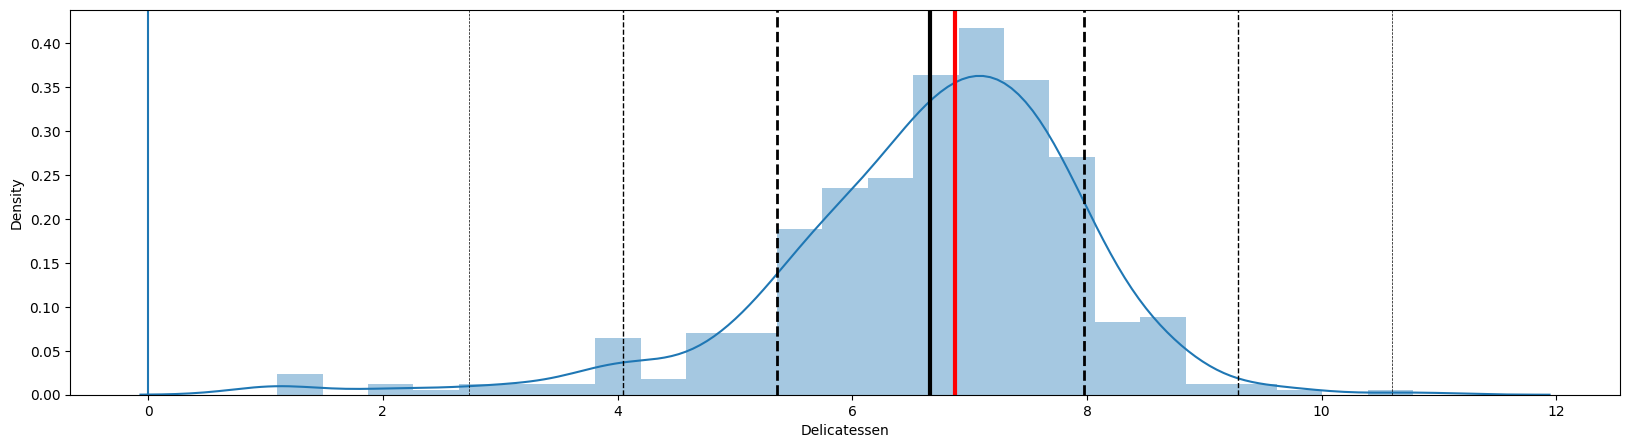

In [27]:
plt.figure(figsize=(20,5))

log_deli = np.log(customers.Delicatessen)

sns.distplot(log_deli)

plt.axvline(log_deli.mean(), color='black', lw=3)
plt.axvline(log_deli.median(), color='red', lw=3)
plt.axvline((log_deli.mean() - log_deli.std()),
            color='black', lw=2, ls="dashed")
plt.axvline((log_deli.mean() + log_deli.std()),
            color='black', lw=2, ls="dashed")
plt.axvline((log_deli.mean() + 2*log_deli.std()),
            color='black', lw=1, ls="dashed")
plt.axvline((log_deli.mean() - 2*log_deli.std()),
            color='black', lw=1, ls="dashed")
plt.axvline((log_deli.mean() + 3*log_deli.std()),
            color='black', lw=.5, ls="dashed")
plt.axvline((log_deli.mean() - 3*log_deli.std()),
            color='black', lw=.5, ls="dashed")
plt.axvline(0)

### Definition: z-score


The z-score of an observation quantifies how many standard deviations the observation is away from the population mean:

#### $$ z_i = \frac{x_i - \text{population mean of x}}{\text{standard deviation of x}} $$


In [28]:
type(customer_features)

pandas.core.frame.DataFrame

In [29]:
customer_features = customers.select_dtypes(exclude=['category'])

In [30]:
customer_features.mean().shape

(6,)

In [32]:
customer_features.mean()

Fresh               12000.297727
Milk                 5796.265909
Grocery              7951.277273
Frozen               3071.931818
Detergents_Paper     2881.493182
Delicatessen         1524.870455
dtype: float64

In [31]:
(customer_features -  customer_features.mean()).shape

(440, 6)

In [34]:
customer_features.std()

Fresh               12647.328865
Milk                 7380.377175
Grocery              9503.162829
Frozen               4854.673333
Detergents_Paper     4767.854448
Delicatessen         2820.105937
dtype: float64

In [33]:
customer_feature_z_scores = (customer_features -  customer_features.mean())/customer_features.std()

In [35]:
customer_feature_z_scores.shape

(440, 6)

In [36]:
np.random.seed(42)
sample = customer_feature_z_scores.sample(4)
sample

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
265,-0.481627,2.402416,0.604822,1.459021,-0.430276,0.748599
78,-0.097594,-0.626156,-0.619191,-0.201029,-0.541227,-0.481496
347,1.216044,0.188030,0.458765,-0.054161,0.364841,-0.178316
255,1.550818,-0.719105,-0.679382,0.035032,-0.581078,-0.322637


In [38]:
customer_feature_z_scores.std()

Fresh               1.0
Milk                1.0
Grocery             1.0
Frozen              1.0
Detergents_Paper    1.0
Delicatessen        1.0
dtype: float64

In [41]:
type(sample)

pandas.core.frame.DataFrame

In [42]:
sample.plot?

Signature:      sample.plot(*args, **kwargs)
Type:           PlotAccessor
String form:    <pandas.plotting._core.PlotAccessor object at 0x1278fc440>
File:           /opt/miniconda3/envs/la-goose/lib/python3.12/site-packages/pandas/plotting/_core.py
Docstring:     
Make plots of Series or DataFrame.

Uses the backend specified by the
option ``plotting.backend``. By default, matplotlib is used.

Parameters
----------
data : Series or DataFrame
    The object for which the method is called.
x : label or position, default None
    Only used if data is a DataFrame.
y : label, position or list of label, positions, default None
    Allows plotting of one column versus another. Only used if data is a
    DataFrame.
kind : str
    The kind of plot to produce:

    - 'line' : line plot (default)
    - 'bar' : vertical bar plot
    - 'barh' : horizontal bar plot
    - 'hist' : histogram
    - 'box' : boxplot
    - 'kde' : Kernel Density Estimation plot
    - 'density' : same as 'kde'
    - 'area'

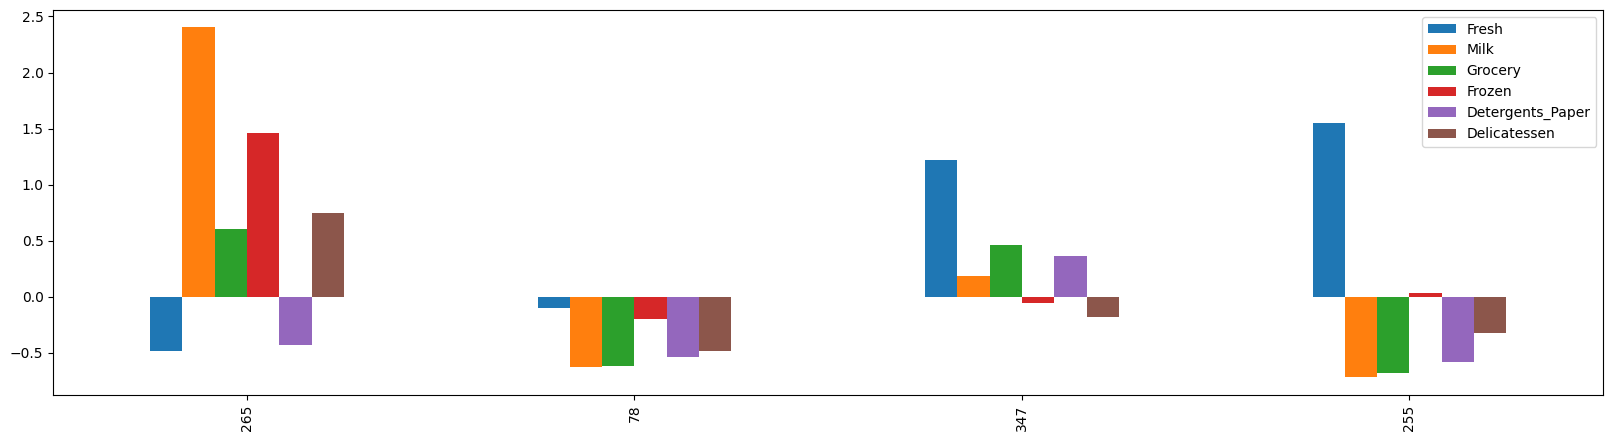

In [40]:
sample.plot(kind='bar', figsize=(20,5))
labels = ["Sample {}".format(i) for i in sample.index]

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/1258057126.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_features['Fresh'], ax=ax[0], bins=100)
/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/1258057126.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.d

<Axes: xlabel='Fresh', ylabel='Density'>

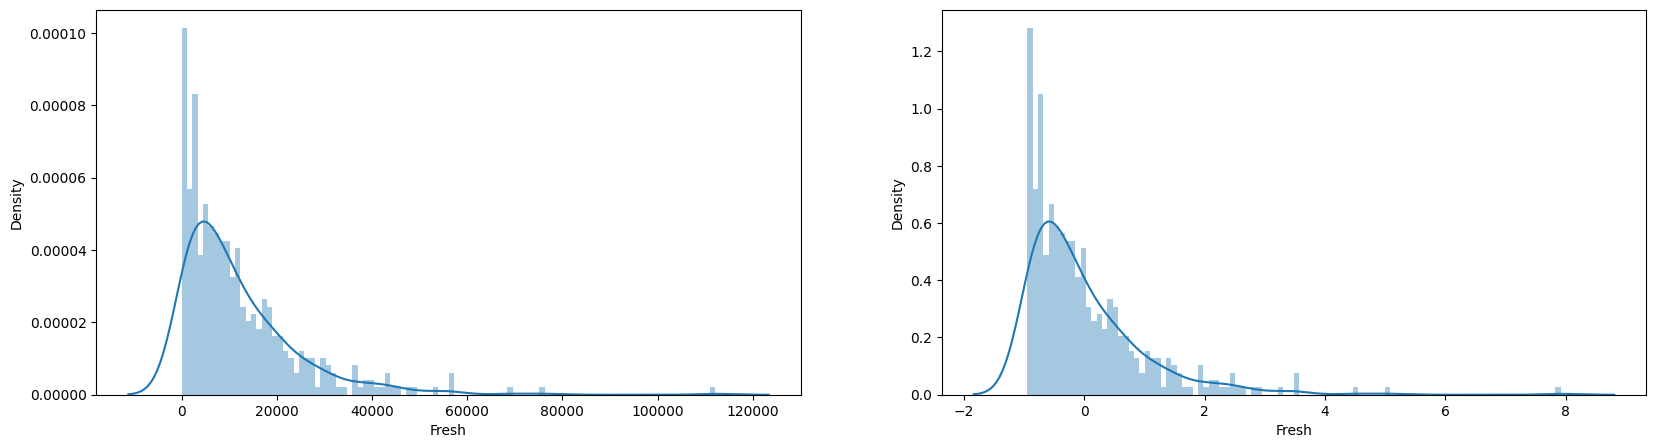

In [43]:
fig, ax = plt.subplots(1,2, figsize=(20,5))

sns.distplot(customer_features['Fresh'], ax=ax[0], bins=100)
sns.distplot(customer_feature_z_scores['Fresh'], ax=ax[1], bins=100)

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/2116589905.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_features['Fresh'], ax=ax[0,0], bins=100)
/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/2116589905.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

(-5.0, 10.0)

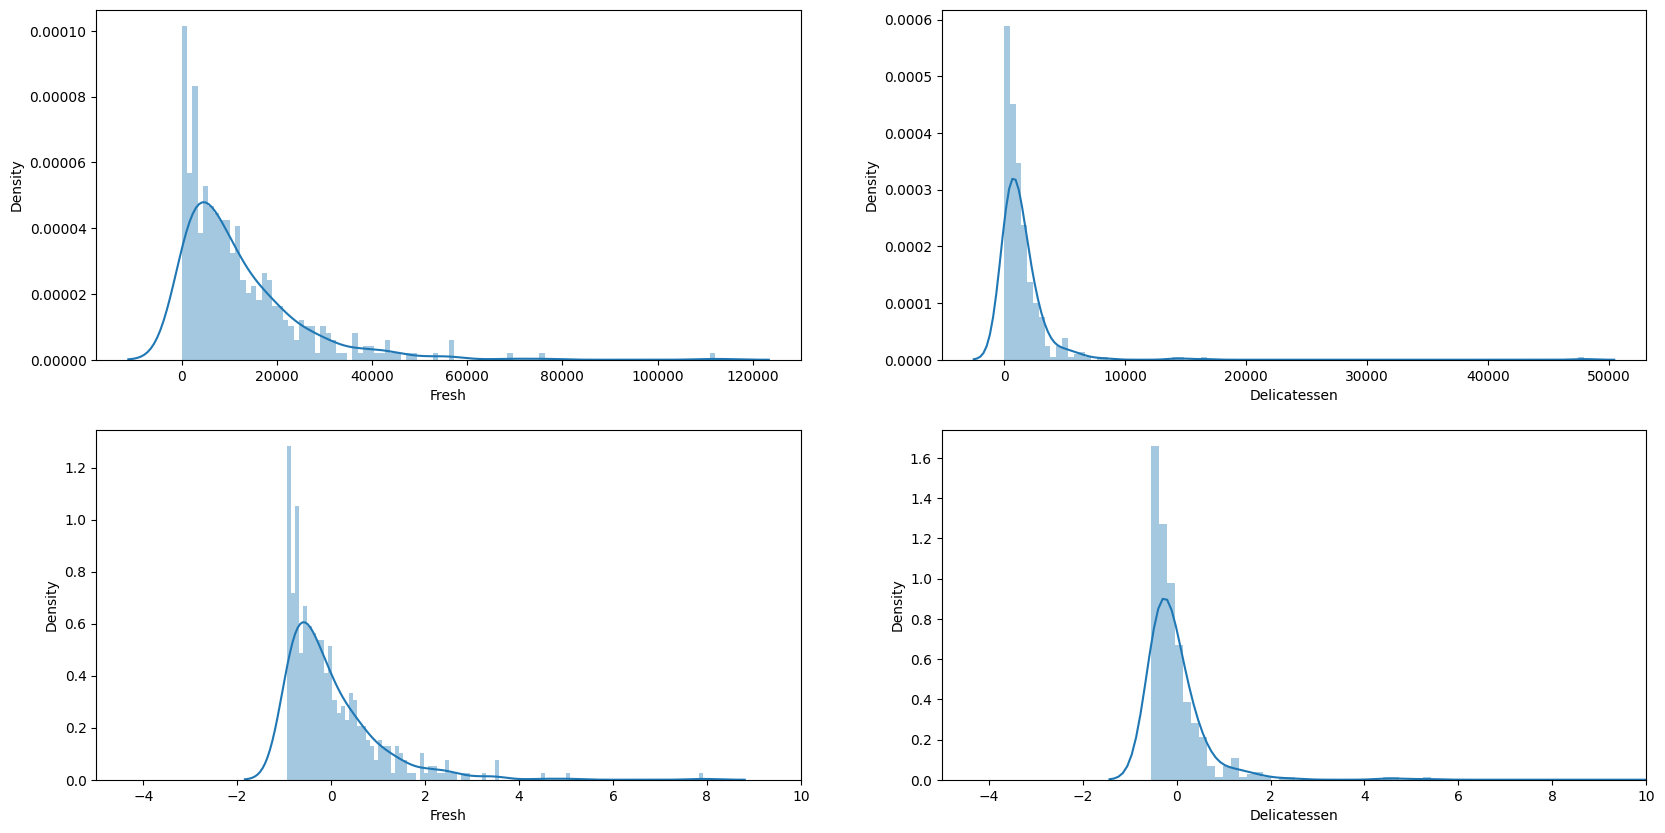

In [49]:
fig, ax = plt.subplots(2,2, figsize=(20,10))

sns.distplot(customer_features['Fresh'], ax=ax[0,0], bins=100)
sns.distplot(customer_features['Delicatessen'], ax=ax[0,1], bins=100)
sns.distplot(customer_feature_z_scores['Fresh'], ax=ax[1,0], bins=100)
ax[1, 0].set_xlim(-5, 10)
sns.distplot(customer_feature_z_scores['Delicatessen'], ax=ax[1,1], bins=100)
ax[1, 1].set_xlim(-5, 10)

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/3121327151.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_features[col])
/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/3121327151.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_feature

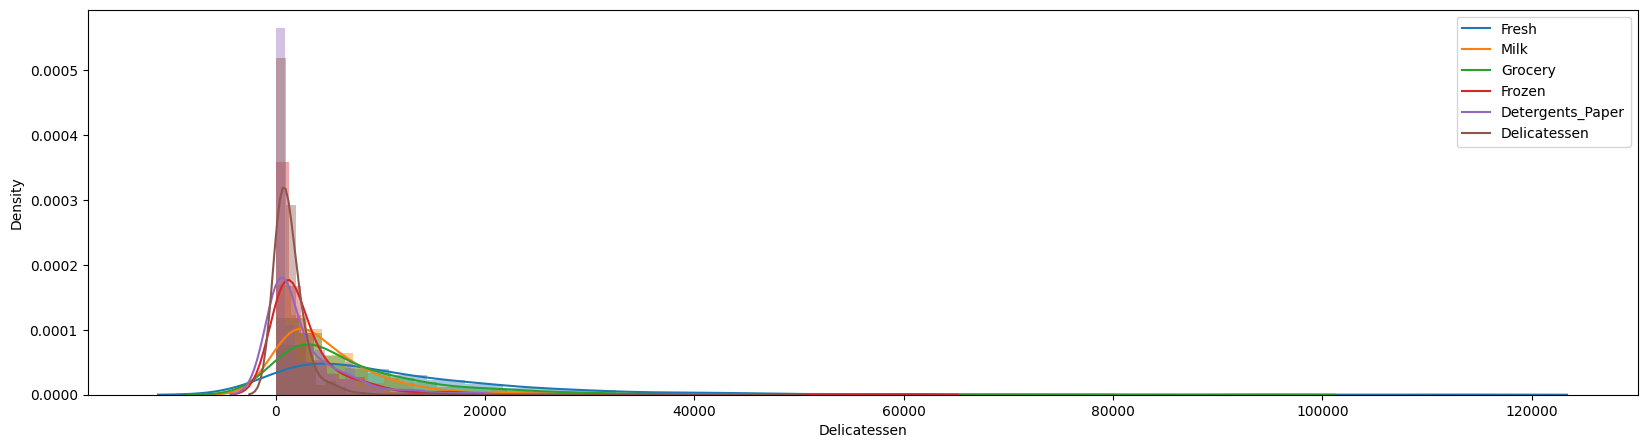

In [54]:
fig, ax = plt.subplots(1,1, figsize=(20,5))

ax.set_xlabel('')
for col in customer_features.columns:
    sns.distplot(customer_features[col])
ax.legend(customer_features.columns)

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/638637615.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_feature_z_scores[col])
/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_53075/638637615.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_f

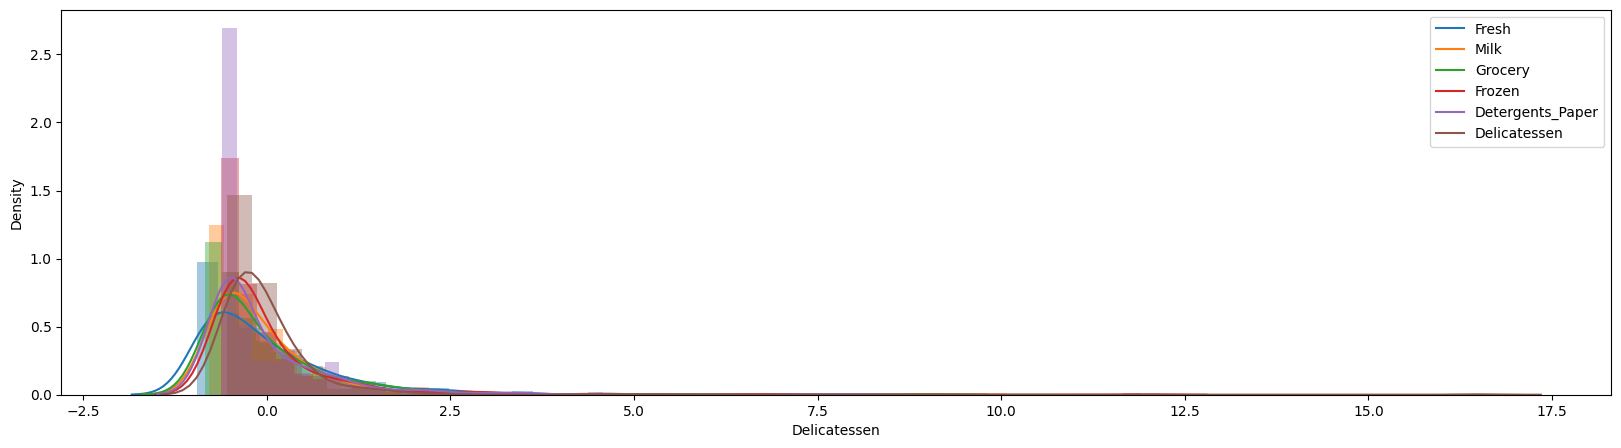

In [55]:
fig, ax = plt.subplots(1,1, figsize=(20,5))

for col in customer_features.columns:
    sns.distplot(customer_feature_z_scores[col])
ax.legend(customer_features.columns)

In [56]:
customer_features.mean()

Fresh               12000.297727
Milk                 5796.265909
Grocery              7951.277273
Frozen               3071.931818
Detergents_Paper     2881.493182
Delicatessen         1524.870455
dtype: float64